# 01. EDA and Preprocessing

CardioCare final project notebook skeleton.


## 1. 기본 라이브러리 불러오기
EDA, 시각화 전처리, train/test split에 필요한 라이브러리 불러오기


In [ ]:
# EDA 및 데이터 전처리에 필요한 기본 라이브러리 임포트하기
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. 프로젝트 경로와 데이터 경로 설정하기

notebooks/ 안에서 실행하는 경우와 프로젝트 루트에서 실행하는 경우를 모두 처리하도록 설정하기


In [ ]:
# 프로젝트 루트 디렉토리 설정 (notebooks/ 안에서 실행 가능하도록 처리하기)
candidate_roots = [
    Path.cwd(), # 현재 작업 디렉토리
    Path.cwd().parent # 상위 디렉토리 
]

# 프로젝트 루트 디렉토리를 저장할 변수 (아직 찾지 못한 상태)
PROJECT_ROOT = None 

# 후보 디렉토리들을 하나씩 확인하기
for root in candidate_roots:
    if (root / "data").exists():
        PROJECT_ROOT = root
        break

# 모든 후보를 확인했는데도 data 폴더를 찾지 못한 경우 -> error  발생 시켜서 실행 중단하기
if PROJECT_ROOT is None:
    raise FileNotFoundError("data 폴더를 찾을 수 없습니다. 노트북 위치와 프로젝트 구조를 확인하십시오.")

DATA_DIR = PROJECT_ROOT / "data" # 데이터 저장 폴더
SRC_DIR = PROJECT_ROOT / "src" # 소스 코드 폴더
REPORTS_DIR = PROJECT_ROOT / "reports" # 결과 보고서 폴더
FIGURES_DIR = REPORTS_DIR / "figures" # 그래프 / 이미지 저장 폴더

SRC_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning
DATA_DIR: c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\data


## 3. 사용할 UCI Heart Disease 파일 목록 정의하기

네 개 기관의 processed.*.data 파일을 통합하고 source 컬럼은 어느 기관 데이터인지 추적하기 위한 EDA용 컬럼 추가하기


In [ ]:
# UCI 심장병 데이터셋의 네 개 기관 파일 목록, 컬럼명, 연속형/범주형 변수 정의
# key : 기관 이름 , value : 실제 데이터 파일명
RAW_FILES = {
    "cleveland": "processed.cleveland.data",
    "hungarian": "processed.hungarian.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}

# 데이터셋의 컬럼(특성) 이름 정의 -> 파일에는 헤더가 없기 때문에 읽어올 때 이 이름들을 사용
COLUMNS = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]
# 연속형(숫자형) 변수 목록
NUMERIC_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
]
# 범주형 변수 목록
CATEGORICAL_FEATURES = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
]

TARGET = "target" # 예측하려는 목표 변수(정답 레이블)
SOURCE = "source" # 데이터 출처(기관명)를 저장할 컬럼 이름

# 각 데이터 파일의 존재 여부 확인
for source_name, file_name in RAW_FILES.items():
    path = DATA_DIR / file_name  # DATA_DIR와 파일명을 결합하여 전체 경로 생성
    print(source_name, "->", path, "exists:", path.exists())   # 기관명, 파일 경로, 파일 존재 여부 출력

cleveland -> c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\data\processed.cleveland.data exists: True
hungarian -> c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\data\processed.hungarian.data exists: True
switzerland -> c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\data\processed.switzerland.data exists: True
va -> c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\data\processed.va.data exists: True


## 4. 데이터 로드 함수 작성하기

?는 결측값이므로 NaN으로 읽고 각 파일을 읽은 뒤 source 컬럼을 붙이고 하나로 합치기


In [ ]:
# 네 개 파일을 읽어서 하나로 통합하는 함수 정의 및 데이터 로드
# 하나의 DataFrame으로 합치는 함수 정의하기
def load_heart_disease_processed_files(data_dir: Path) -> pd.DataFrame:
    frames = [] # 각 기관의 데이터를 저장할 리스트

    # cleveland, hungarian, switzerland, va 파일을 순회
    for source_name, file_name in RAW_FILES.items():
        file_path = data_dir / file_name

        if not file_path.exists():
            raise FileNotFoundError(f"필수 데이터 파일이 없습니다: {file_path}")

        temp_df = pd.read_csv(
            file_path,
            header=None, # 원본 데이터에 헤더가 없으므로 첫 줄도 데이터로 읽음
            names=COLUMNS,
            na_values="?"  # ? 값을 결측치(NaN)로 처리
        )

        temp_df[SOURCE] = source_name
        frames.append(temp_df)
    # 네 개의 데이터프레임을 하나로 합침
    df = pd.concat(frames, ignore_index=True)
    # 변환 불가능한 값은 NaN으로 처리
    for col in COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


raw_df = load_heart_disease_processed_files(DATA_DIR)

print("통합 데이터 shape:", raw_df.shape)
raw_df.head()

통합 데이터 shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


## 5. 기본 정보 확인하기

head(), info(), describe()를 사용하여 기본 정보 확인해보기

In [ ]:
# 로드된 데이터의 처음 5행 확인하기
display(raw_df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
# 데이터의 데이터 타입, 결측값, 메모리 정보 확인하기
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
 14  source    920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


In [ ]:
# 데이터의 기본 통계량 확인하기 (평균, 최솟값, 최댓값 등)
display(raw_df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 6. 기관별 데이터 개수 확인하기
네 개 데이터셋이 정상적으로 통합되었는지 확인하기

In [ ]:
# 기관별(source) 샘플 개수 집계
source_counts = raw_df[SOURCE].value_counts().rename_axis("source").reset_index(name="count")
display(source_counts)

,source,count
0,cleveland,303
1,hungarian,294
2,va,200
3,switzerland,123


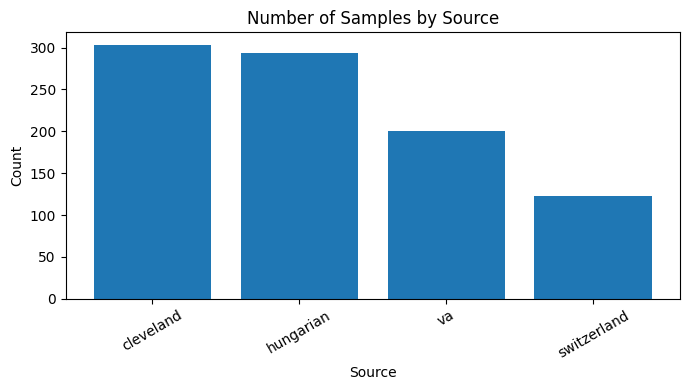

In [ ]:
# 기관별 샘플 개수를 막대 그래프로 시각화
plt.figure(figsize=(7, 4))
plt.bar(source_counts["source"], source_counts["count"])
plt.title("Number of Samples by Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. 원래 target 분포 확인
0 = 정상
1, 2, 3, 4 = 심장병 있음

UCI 원본 target은 다중 클래스이므로 다음 단계에서 이진 분류 문제로 바꾼다.

In [ ]:
# target 값들에 대한 각각의 개수와 비율 구해서 DataFrame으로 정리하기
# 원본 target의 분포 확인 (0=정상, 1~4=심장병)
target_original_counts = raw_df[TARGET].value_counts(dropna=False).sort_index() # target 컬럼의 각 값(0~4)이 몇 개 있는지 계산, dropna=False : 결측치(NaN)가 있으면 함께 계산
target_original_ratio = raw_df[TARGET].value_counts(normalize=True, dropna=False).sort_index() # target 컬럼의 비율 계산, normalize=True : 개수가 아니라 비율로 계산

# 개수와 비율을 하나의 DataFrame으로 정리하기
target_original_summary = pd.DataFrame({
    "count": target_original_counts,
    "ratio": target_original_ratio
})

display(target_original_summary)

,count,ratio
target,,
0,411,0.446739
1,265,0.288043
2,109,0.118478
3,107,0.116304
4,28,0.030435


## 8. target 이진화 후 분포 확인하기
target > 0 이면 심장병 있음으로 처리하기

In [ ]:
# target을 이진화 (0=정상, 1=심장병 있음)하고 클래스 분포 확인하기
eda_df = raw_df.copy() # 원본 데이터프레임을 복사하여 EDA용 데이터프레임 생성
eda_df["target_binary"] = (eda_df[TARGET] > 0).astype(int) # target 컬럼의 값이 0보다 크면 1(심장병 있음), 0이면 0(정상)으로 변환하여 새로운 컬럼 target_binary 생성하기

binary_counts = eda_df["target_binary"].value_counts().sort_index() # 각 클래스에서 (0,1)의 개수 계산
binary_ratio = eda_df["target_binary"].value_counts(normalize=True).sort_index() # 각 클래스의 비율 계산

# DataFrame으로 정리하기
binary_summary = pd.DataFrame({
    "class_name": ["normal", "heart_disease"],
    "count": binary_counts.values,
    "ratio": binary_ratio.values
}, index=binary_counts.index)

display(binary_summary)

,class_name,count,ratio
target_binary,,,
0,normal,411,0.446739
1,heart_disease,509,0.553261


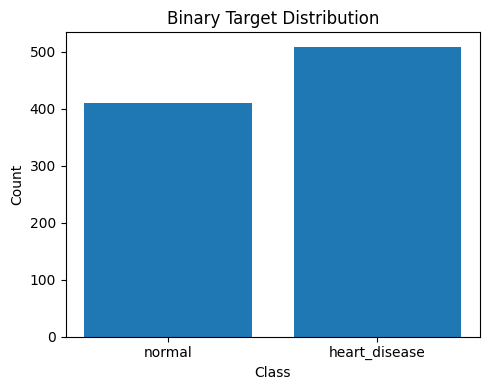

In [ ]:
# 이진화된 target의 클래스 분포를 막대 그래프로 시각화
plt.figure(figsize=(5, 4))
plt.bar(["normal", "heart_disease"], binary_counts.values)
plt.title("Binary Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 9. 기관별 target 분포 확인하기

In [ ]:
# 기관별 target 비율의 교차표 생성
# normalize = 'index': 각 행(기관별) 합계가 1이 되도록 비율 계산
source_target_table = pd.crosstab(
    eda_df[SOURCE],
    eda_df["target_binary"],
    normalize="index"
)
# 컬럼명을 보기 쉽게 변경하기 ( 0 : normal_ratio , 1 : heart_disease_ratio )
source_target_table.columns = ["normal_ratio", "heart_disease_ratio"]

display(source_target_table)

,normal_ratio,heart_disease_ratio
source,,
cleveland,0.541254,0.458746
hungarian,0.639456,0.360544
switzerland,0.065041,0.934959
va,0.255000,0.745000


In [ ]:
# 기관별 target 개수의 교차표 생성
# 행 : 기관명, 열 : 정상(0), 심장병(1)
source_target_count = pd.crosstab(
    eda_df[SOURCE],
    eda_df["target_binary"]
)
# 컬럼명을 좀 더 보기 쉽게 변경하기
source_target_count.columns = ["normal_count", "heart_disease_count"]

display(source_target_count)

,normal_count,heart_disease_count
source,,
cleveland,164,139
hungarian,188,106
switzerland,8,115
va,51,149


## 10. 결측값 분석하기
열별 결측 개수와 결측률 확인하기 

In [ ]:
# 각 컬럼별 결측값 개수와 비율 분석
missing_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(), # 결측값 개수
    "missing_ratio": raw_df.isna().mean() # 결측값 비율 
}).sort_values("missing_ratio", ascending=False) # 결측 비율이 높은 컬럼부터 정렬 

total_missing = int(raw_df.isna().sum().sum()) # 데이터 전체에서 발생한 결측값 총 개수 계산하기

display(missing_summary)
print("전체 결측값 개수:", total_missing)

,missing_count,missing_ratio
ca,611,0.664130
thal,486,0.528261
slope,309,0.335870
fbs,90,0.097826
oldpeak,62,0.067391
trestbps,59,0.064130
thalach,55,0.059783
exang,55,0.059783
chol,30,0.032609
restecg,2,0.002174


전체 결측값 개수: 1759


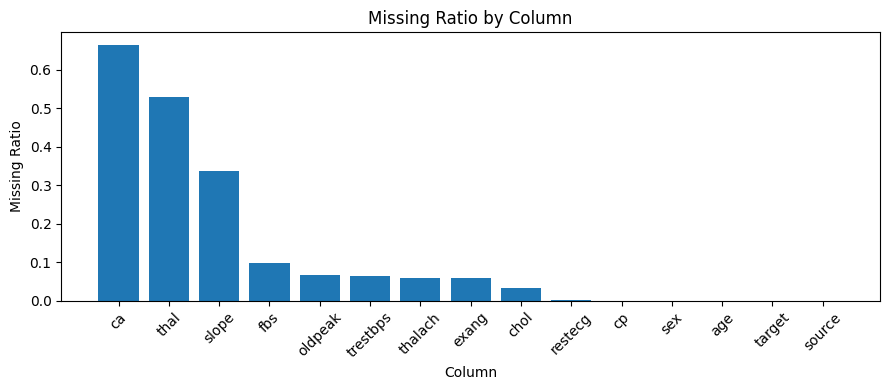

In [ ]:
# 각 컬럼의 결측 비율을 막대 그래프로 시각화
plt.figure(figsize=(9, 4))
plt.bar(missing_summary.index, missing_summary["missing_ratio"])
plt.title("Missing Ratio by Column")
plt.xlabel("Column")
plt.ylabel("Missing Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. 임상적으로 불가능하거나 비정상적인 값 확인하기
chol = 0 처럼 실제 측정값으로 보기 어려운 값들을 삭제하지 않고 NaN으로 바꾼 뒨 전처리 파이프라인에서 대치하기

In [ ]:
# 임상적으로 불가능한 값 확인하기
invalid_value_summary = {
    "age_less_equal_0": (raw_df["age"] <= 0).sum(),
    "trestbps_less_equal_0": (raw_df["trestbps"] <= 0).sum(),
    "chol_less_equal_0": (raw_df["chol"] <= 0).sum(),
    "thalach_less_equal_0": (raw_df["thalach"] <= 0).sum(),
    "oldpeak_less_0": (raw_df["oldpeak"] < 0).sum(),
}

invalid_value_summary = pd.DataFrame.from_dict(
    invalid_value_summary,
    orient="index",
    columns=["count"]
)

display(invalid_value_summary)

,count
age_less_equal_0,0
trestbps_less_equal_0,1
chol_less_equal_0,172
thalach_less_equal_0,0
oldpeak_less_0,12


## 12. 중복 행 확인하기

In [ ]:
# 중복된 행의 개수와 비율 확인하기
duplicate_count = raw_df.duplicated().sum()

print("중복 행 개수:", duplicate_count)
print("중복 비율:", duplicate_count / len(raw_df))

중복 행 개수: 2
중복 비율: 0.002173913043478261


## 13. 연속형 변수 분포 시각화
age, trestbps, chol, thalach, oldpeak의 분포 확인하기

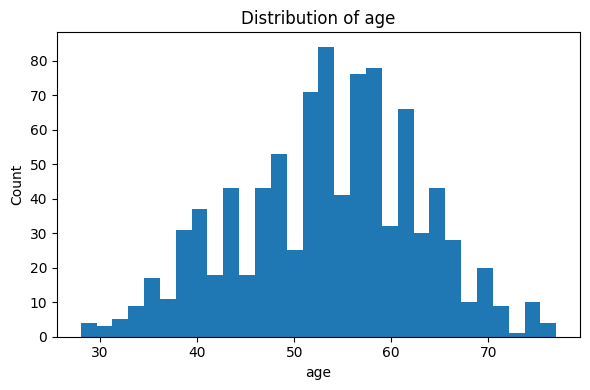

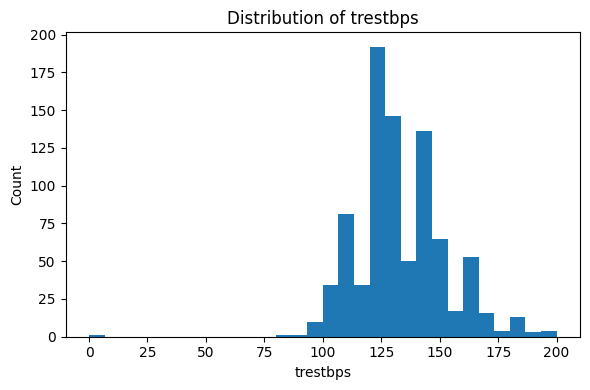

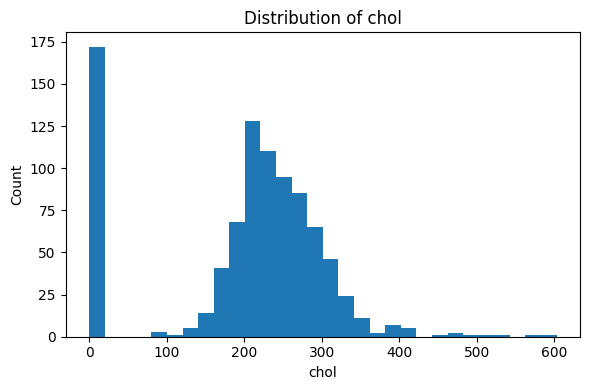

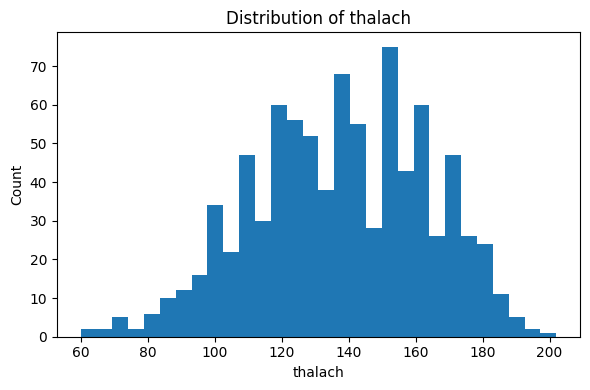

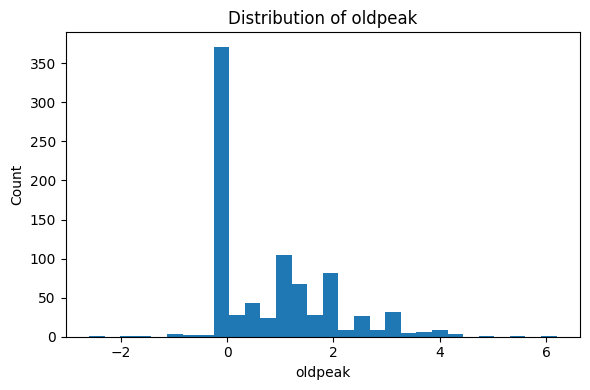

In [ ]:
# 연속형 변수들의 분포를 히스토그램으로 시각화
for col in NUMERIC_FEATURES:
    plt.figure(figsize=(6, 4))
    plt.hist(raw_df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 14. 연속형 변수 boxplot 
이상치 시각화하기

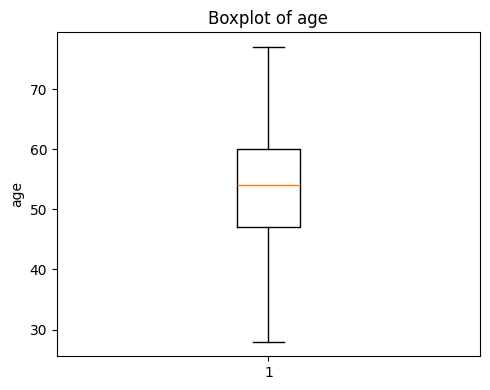

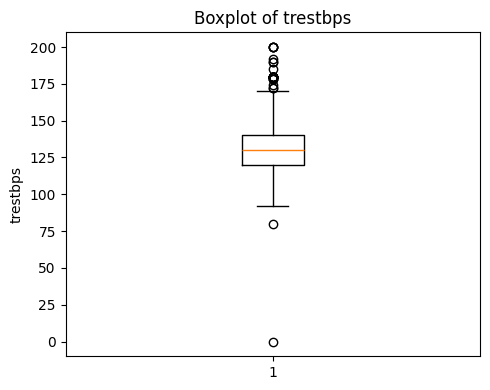

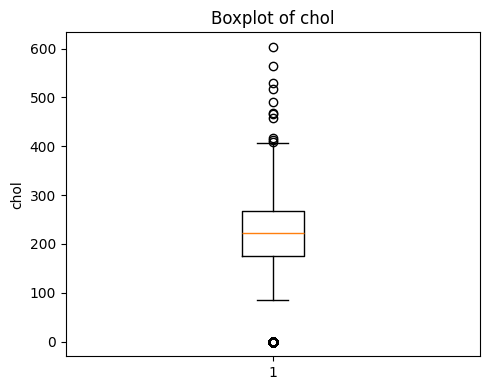

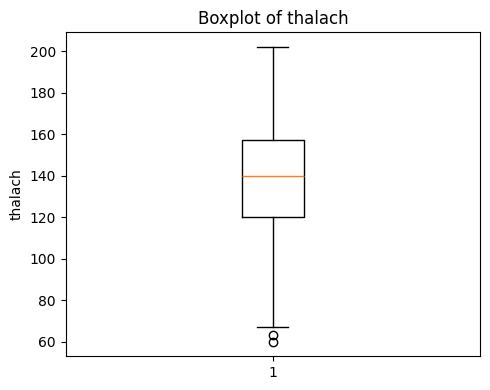

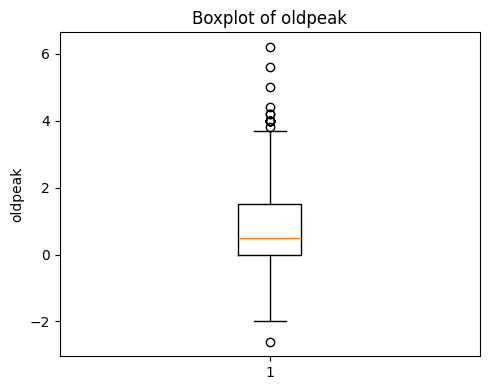

In [ ]:
# 연속형 변수들의 boxplot으로 이상치 시각화
for col in NUMERIC_FEATURES:
    plt.figure(figsize=(5, 4))
    plt.boxplot(raw_df[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 15. IQR 기반 이상치 탐지하기
의료 데이터에서는 극단값이 실제 위험 신호일 수 있으므로 삭제하기 않고 일단 분석만 하기

In [ ]:
# IQR 기반 이상치 탐지로 각 변수별 이상치 개수와 비율 계산
def detect_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []

    for col in columns:
        series = df[col].dropna()  # 결측치를 제거한 해당 변수 데이터 추출하기

        q1 = series.quantile(0.25) # 제 1분위 (25%)
        q3 = series.quantile(0.75) # 제 3분위 (75%)
        iqr = q3 - q1 # 이상치 범위 계산하기 

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound) # 하한보다 작거나 상한보다 큰 값을 이상치로 판정
        outlier_count = outlier_mask.sum()   # 이상치 개수 계산
        outlier_ratio = outlier_count / df[col].notna().sum() # 이상치 비율

        rows.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_ratio": outlier_ratio,
        })

    return pd.DataFrame(rows)


outlier_summary = detect_outliers_iqr(raw_df, NUMERIC_FEATURES)
display(outlier_summary)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_ratio
0,age,47.0,60.0,13.0,27.50,79.50,0,0.000000
1,trestbps,120.0,140.0,20.0,90.00,170.00,28,0.032520
2,chol,175.0,268.0,93.0,35.50,407.50,183,0.205618
3,thalach,120.0,157.0,37.0,64.50,212.50,2,0.002312
4,oldpeak,0.0,1.5,1.5,-2.25,3.75,16,0.018648


## 16. EDA 기반 전처리 결정 정리하기

EDA 결과, 네 개 기관의 processed 데이터를 통합한 뒤 `ca`의 결측률은 약 66.4%, `thal`의 결측률은 약 52.8%로 매우 높게 나타났다. 따라서 이 두 변수는 삭제 후보로 두고, 나머지 변수의 결측값은 학습 데이터에만 fit되는 imputer로 대치하도록 전처리 방향을 정했다. 또한 중복 행이 2개 확인되어 전처리 단계에서 중복 제거를 함께 수행한다.

연속형 변수의 이상치는 boxplot과 IQR로 확인했으며, 특히 `chol`은 IQR 기준 이상치 비율이 약 20.6%로 크게 나타났다. 하지만 의료 데이터에서는 극단값 자체가 위험 신호일 수 있으므로 이상치를 일괄 삭제하지 않는다. 대신 임상적으로 불가능한 값만 정리하는 방향으로 두었고, 실제로 `chol <= 0` 값이 172개, `oldpeak < 0` 값이 12개 확인되어 이런 값들은 NaN으로 바꾼 뒤 전처리 파이프라인에서 대치한다.

타깃 이진화 후 분포는 정상 411건(약 44.7%), 심장병 509건(약 55.3%)으로 완전히 균등하지 않았다. 따라서 이후 모델 평가는 accuracy만 사용하지 않고 balanced accuracy, precision, recall, F1을 함께 사용한다. 특히 심장병 환자를 정상으로 예측하는 false negative 위험을 줄이는 것이 중요하므로 recall도 함께 중요하게 본다.

In [ ]:
# EDA 결과 바탕으로 전처리 전략 결정 (결측률 50% 이상 컬럼 제외, 나머지는 대치)
MISSING_DROP_THRESHOLD = 0.5

# 분석에 사용할 전체 특성(수치형 + 범주형) 목록 생성
feature_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES

missing_ratio = raw_df[feature_columns].isna().mean()
# 결측치 비율이 50% 이상인 특성만 선택
high_missing_features = (
    missing_ratio[missing_ratio >= MISSING_DROP_THRESHOLD]
    .index
    .tolist()
)

# 모델 학습에 사용하지 않을 컬럼 수동 지정
manual_drop_features = [SOURCE] # source는 데이터 출처 정보이므로 제거
# set()으로 중복 제거 후 정렬
drop_features = sorted(set(high_missing_features + manual_drop_features))
# 제거 대상이 아닌 수치형 변수만 선택하기
selected_numeric_features = [
    col for col in NUMERIC_FEATURES
    if col not in drop_features
]

# 제거 대상이 아닌 범주형 변수만 선택하기
selected_categorical_features = [
    col for col in CATEGORICAL_FEATURES
    if col not in drop_features
]

# 전처리 결정 사항을 딕셔너리 형태로 정리하기
preprocessing_decision = {
    "missing_drop_threshold": MISSING_DROP_THRESHOLD,
    "high_missing_features": high_missing_features,
    "drop_features": drop_features,
    "selected_numeric_features": selected_numeric_features,
    "selected_categorical_features": selected_categorical_features,
}

preprocessing_decision

NameError: name 'NUMERIC_FEATURES' is not defined

## 17. 전처리 함수 작성하기
타깃 이진화, 중복 제거, 빈 컬럼 제거, 임상적으로 불가능한 값의 NaN 변환하기

In [ ]:
# 데이터 정리 함수: 타깃 이진화, 중복 제거, 임상적 불가능값을 NaN으로 변환
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    #모델 학습 전에 반복 적용할 수 있는 기본 정리 함수임
    cleaned = df.copy()

    # 완전히 비어 있는 컬럼과 완전 중복 행은 정보가 없으므로 제거
    cleaned = cleaned.dropna(axis=1, how="all")
    cleaned = cleaned.drop_duplicates()

    # UCI 원본 target은 0~4이므로, 과제 요구사항에 맞게 0/1 이진 분류로 변환
    cleaned[TARGET] = (cleaned[TARGET] > 0).astype(int)

    # 임상적으로 불가능한 값은 삭제하지 않고 NaN으로 바꿔 이후 imputer가 처리하게함
    cleaned.loc[cleaned["age"] <= 0, "age"] = np.nan
    cleaned.loc[cleaned["trestbps"] <= 0, "trestbps"] = np.nan
    cleaned.loc[cleaned["chol"] <= 0, "chol"] = np.nan
    cleaned.loc[cleaned["thalach"] <= 0, "thalach"] = np.nan
    cleaned.loc[cleaned["oldpeak"] < 0, "oldpeak"] = np.nan

    return cleaned


clean_df = clean_dataframe(raw_df)

print("원본 shape:", raw_df.shape)
print("정리 후 shape:", clean_df.shape)

display(clean_df.head())

원본 shape: (920, 15)
정리 후 shape: (918, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


## 18. 정리 후 결측값 재확인하기

In [ ]:
# 정리 후 데이터의 결측값 재확인
clean_missing_summary = pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_ratio": clean_df.isna().mean()
}).sort_values("missing_ratio", ascending=False)

display(clean_missing_summary)

,missing_count,missing_ratio
ca,609,0.663399
thal,484,0.527233
slope,307,0.334423
chol,201,0.218954
fbs,90,0.098039
oldpeak,74,0.080610
trestbps,60,0.065359
thalach,55,0.059913
exang,55,0.059913
restecg,2,0.002179


## 19. 최종 입력 변수와 타깃 분리

In [ ]:
# 입력 변수(X)와 타깃(y) 분리
def split_features_target(
    df: pd.DataFrame,
    drop_features: list[str]
) -> tuple[pd.DataFrame, pd.Series]:
    # target과 학습에서 제외할 컬럼(source 등)을 분리해 모델 입력 X만 남김
    X = df.drop(columns=[TARGET], errors="ignore")
    X = X.drop(columns=drop_features, errors="ignore")
    y = df[TARGET].astype(int)

    return X, y


X, y = split_features_target(clean_df, drop_features)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("사용 변수:", X.columns.tolist())

X shape: (918, 11)
y shape: (918,)
사용 변수: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']


## 20. train/test split
데이터 누수를 막기 위해 train/test 먼저 나누기

In [ ]:
# 데이터 누수 방지를 위해 train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("y_test distribution:")
display(y_test.value_counts(normalize=True).sort_index())

X_train: (734, 11)
X_test: (184, 11)
y_train distribution:


target
0    0.446866
1    0.553134
Name: proportion, dtype: float64

y_test distribution:


target
0    0.445652
1    0.554348
Name: proportion, dtype: float64

## 21. sklearn 전처리 pipeline 구성하기
* 수치형 변수 : 중앙값 대치와 표준화 적용하기
* 범주형 변수 : 최빈값 대치와 One-Hot Encoding 적용하기
* 데이터 누수 방지 : train/test split 이후 train 데이터에만 `fit_transform`, test 데이터에는 `transform`만 적용하기


In [ ]:
# sklearn Pipeline: 연속형은 중앙값 대치+표준화, 범주형은 최빈값 대치+One-Hot Encoding
def build_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str]
) -> ColumnTransformer:
    # 수치형은 중앙값 대치 후 표준화합니다. fit은 train split에서만 수행함
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    # 범주형은 최빈값 대치 후 one-hot encoding으로 모델이 읽을 수 있게 변환
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop"
    )

    return preprocessor


preprocessor = build_preprocessor(
    selected_numeric_features,
    selected_categorical_features
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope'])])

## 22. 전처리 pipeline 동작 확인하기
fit_transform을 X_train에만 수행하고 X_test에는 transform만 적용하여 데이터 누수 방지하기

In [ ]:
# 전처리 파이프라인 적용 (train에만 fit_transform, test에는 transform만 적용)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("전처리 후 X_train shape:", X_train_processed.shape)
print("전처리 후 X_test shape:", X_test_processed.shape)

전처리 후 X_train shape: (734, 21)
전처리 후 X_test shape: (184, 21)


## 23. 전처리 후 결측값 확인하기
전처리 후 결측값이 남아 있지 않는지 확인해보기

In [ ]:
# 전처리 후 데이터의 결측값 확인
def to_dense_array(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return matrix


X_train_dense = to_dense_array(X_train_processed)
X_test_dense = to_dense_array(X_test_processed)

print("X_train_processed NaN 개수:", np.isnan(X_train_dense).sum())
print("X_test_processed NaN 개수:", np.isnan(X_test_dense).sum())

X_train_processed NaN 개수: 0
X_test_processed NaN 개수: 0


## 24. 전처리 후 생성된 feature name 확인하기
One-Hot Encoding 이후 실제 모델에 들어가는 변수 이름 확인하기

In [ ]:
# One-Hot Encoding 후 생성된 최종 feature 이름 확인
feature_names = preprocessor.get_feature_names_out()

feature_names_df = pd.DataFrame({
    "feature_name": feature_names
})

display(feature_names_df.head(30))
print("전체 전처리 후 feature 개수:", len(feature_names))

,feature_name
0,num__age
1,num__trestbps
2,num__chol
3,num__thalach
4,num__oldpeak
5,cat__sex_0.0
6,cat__sex_1.0
7,cat__cp_1.0
8,cat__cp_2.0
9,cat__cp_3.0


전체 전처리 후 feature 개수: 21


## 25. 전처리 결과 일부 확인하기

In [ ]:
# 전처리된 훈련 데이터의 처음 5행 샘플 확인
preview_df = pd.DataFrame(
    X_train_dense[:5],
    columns=feature_names
)

display(preview_df)

,num__age,num__trestbps,num__chol,num__thalach,num__oldpeak,cat__sex_0.0,cat__sex_1.0,cat__cp_1.0,cat__cp_2.0,cat__cp_3.0,cat__cp_4.0,cat__fbs_0.0,cat__fbs_1.0,cat__restecg_0.0,cat__restecg_1.0,cat__restecg_2.0,cat__exang_0.0,cat__exang_1.0,cat__slope_1.0,cat__slope_2.0,cat__slope_3.0
0,-0.275038,-0.676985,-0.108875,-0.429768,0.594092,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,-1.346579,-0.676985,0.905502,1.276224,-0.863665,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.689348,0.994790,0.223103,0.760459,1.663114,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,0.046424,-0.398356,-0.551513,0.085997,-0.863665,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.475040,-1.791502,-0.219535,0.720785,-0.766481,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 26. EDA 그림 저장하기

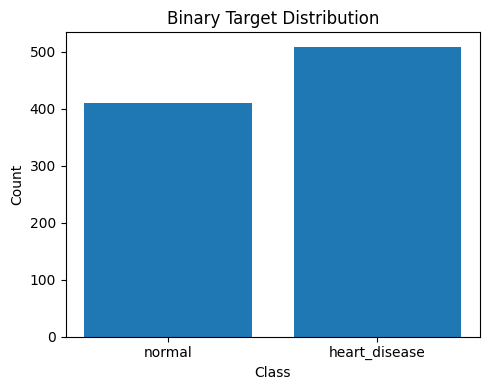

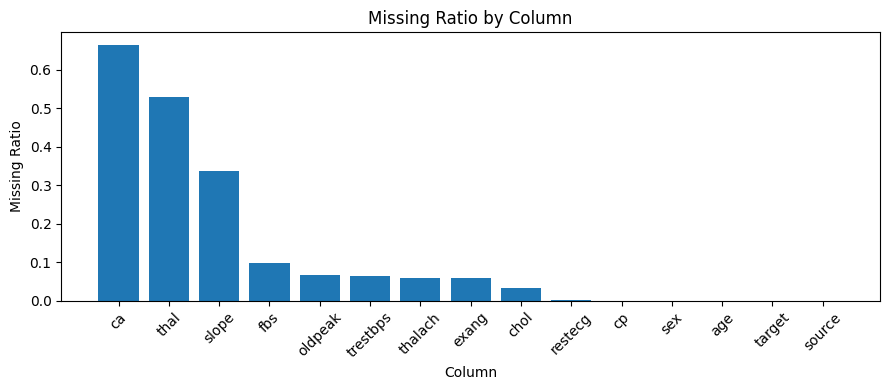

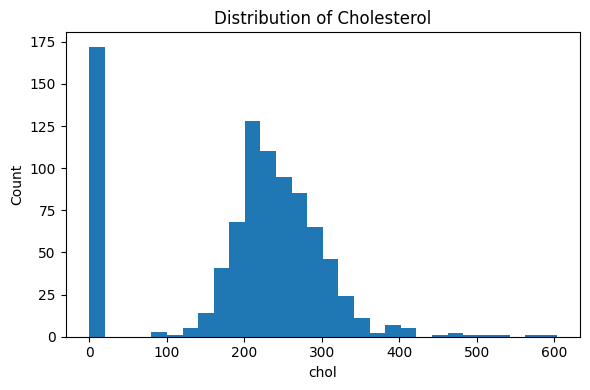

In [ ]:
# EDA 분석 그림들을 figures 폴더에 저장
plt.figure(figsize=(5, 4))
plt.bar(["normal", "heart_disease"], binary_counts.values)
plt.title("Binary Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(missing_summary.index, missing_summary["missing_ratio"])
plt.title("Missing Ratio by Column")
plt.xlabel("Column")
plt.ylabel("Missing Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_ratio_by_column.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(raw_df["chol"].dropna(), bins=30)
plt.title("Distribution of Cholesterol")
plt.xlabel("chol")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chol_distribution.png", dpi=300)
plt.show()

## 27. EDA 결과 요약 표 저장하기

In [ ]:
# EDA 요약 표들을 reports/tables 폴더에 CSV로 저장
eda_output_dir = REPORTS_DIR / "tables"
eda_output_dir.mkdir(exist_ok=True)

source_counts.to_csv(eda_output_dir / "source_counts.csv", index=False)
binary_summary.to_csv(eda_output_dir / "binary_target_summary.csv")
missing_summary.to_csv(eda_output_dir / "missing_summary_raw.csv")
clean_missing_summary.to_csv(eda_output_dir / "missing_summary_cleaned.csv")
outlier_summary.to_csv(eda_output_dir / "outlier_summary_iqr.csv", index=False)
feature_names_df.to_csv(eda_output_dir / "preprocessed_feature_names.csv", index=False)

print("EDA tables saved to:", eda_output_dir)

EDA tables saved to: c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\reports\tables


## 28. 정리된 데이터 저장하기

In [ ]:
# 정리된 데이터를 CSV로 저장
clean_output_path = DATA_DIR / "heart_disease_cleaned_base.csv"
clean_df.to_csv(clean_output_path, index=False)
print("Saved:", clean_output_path)

Saved: c:\Users\jiwoo\OneDrive\Documents\기계학습_기말\202221066_final_machine_learning\202221066_final_machine_learning\data\heart_disease_cleaned_base.csv
